# 00 — Data Exploration

Before building any pipeline, I spent time understanding what's actually in this dataset, since the assignment FAQ explicitly invites relabeling/augmenting if the data doesn't map cleanly to the three call types.

**Key finding:** this dataset is for a fictional B2B company, "Aegis Cloud" (a cybersecurity/compliance SaaS vendor). It's richer than a flat transcript dump — each call folder includes a pre-existing LLM-generated summary, topic tags, sentiment score, key moments, and action items, alongside the raw sentence-level transcript with per-line speaker and sentiment tags. This looks like an export from a meeting-recording tool (Fireflies/Otter/Gong-style).

I treat these pre-existing fields as a **baseline to validate against**, not ground truth — see the design-decision notes in Tasks 1 and 2.

In [1]:
import sys, os
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from load_data import load_all_transcripts

sns.set_style("whitegrid")
df = load_all_transcripts()
print(df.shape)
df.columns.tolist()

(100, 16)


['call_id',
 'title',
 'call_type',
 'company',
 'host',
 'all_emails',
 'num_participants',
 'start_time',
 'duration_min',
 'transcript_text',
 'baseline_summary',
 'baseline_topics',
 'baseline_sentiment_label',
 'baseline_sentiment_score',
 'baseline_action_items',
 'baseline_key_moments']

## Call type derivation

No `call_type` field exists in the raw data. I derived it with a transparent heuristic:
- Title contains "Support Case" → **support**
- All participant emails share `@aegiscloud.com` → **internal**
- Otherwise (Aegis + ≥1 external domain) → **external**

Validated by reading all 100 titles — this cleanly separates the data without needing to relabel or generate synthetic transcripts.

In [2]:
df["call_type"].value_counts()

call_type
external    43
internal    30
support     27
Name: count, dtype: int64

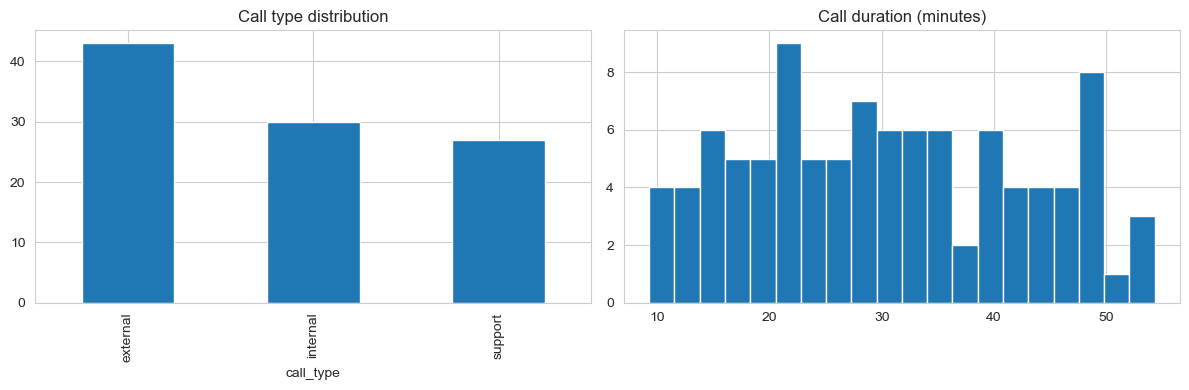

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df["call_type"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Call type distribution")

df["duration_min"].hist(bins=20, ax=axes[1])
axes[1].set_title("Call duration (minutes)")

plt.tight_layout()
plt.show()

Date range: 2026-02-03 10:00:00+00:00 to 2026-04-28 12:45:00+00:00


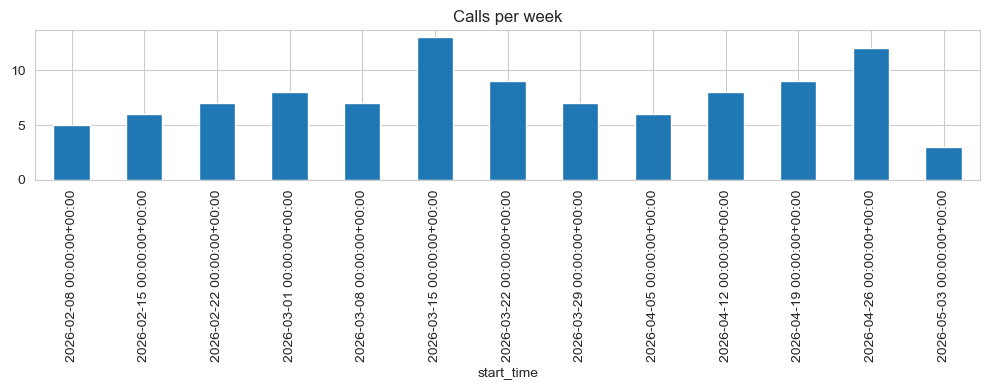

In [4]:
# Date range covered
print("Date range:", df["start_time"].min(), "to", df["start_time"].max())
df.set_index("start_time").resample("W").size().plot(kind="bar", figsize=(10,4), title="Calls per week")
plt.tight_layout()
plt.show()

In [5]:
# Which customer companies appear, and how often (external + support calls)
company_counts = df[df["company"].notna()]["company"].value_counts()
print(f"{len(company_counts)} distinct customer companies across {company_counts.sum()} external/support calls")
company_counts.head(15)

32 distinct customer companies across 70 external/support calls


company
silverlinebrands      4
blackridgeinvest      4
brightpathcommerce    4
coastalliving         4
vantahealth           3
crestlinewealth       3
forgeindustries       3
ridgelinelogistics    3
summittrust           3
meridiancapital       3
stratoscloud          2
clearwatermed         2
cobaltsoftware        2
novaretail            2
frostbyte             2
Name: count, dtype: int64

## Initial observations

- 100 calls split realistically across all three required call types (43 external / 30 internal / 27 support) — no relabeling or synthetic data was needed.
- The data spans roughly a quarter and includes a real, traceable incident narrative (a "Detect" product outage) that touches all three call types — explored fully in the bonus insights notebook.
- Most customer accounts appear in only 1-4 calls each — worth noting as a limitation for any per-account trend analysis (e.g. the churn-risk idea described in the bonus notebook would need more history per account to be reliable).